#23070521113_VedantRajekar
## 1. Data Loading and Preprocessing (MNIST Dataset)

In [ ]:
# Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [ ]:
# Load the MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Reshape and normalize the images
# Images are 28x28, add a channel dimension for Conv2D layers
x_train = x_train.reshape((len(x_train), 28, 28, 1)).astype('float32') / 255.
x_test = x_test.reshape((len(x_test), 28, 28, 1)).astype('float32') / 255.

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


## 2. Convolutional Autoencoder Model Definition

In [ ]:
# Define the input shape
input_img = Input(shape=(28, 28, 1))

# --- Encoder --- #
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x) # Output: 14x14x32
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x) # Output: 14x14x64
x = MaxPooling2D((2, 2), padding='same')(x) # Output: 7x7x64
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x) # Output: 7x7x128
encoded = MaxPooling2D((2, 2), padding='same')(x) # Output: 4x4x128 (approx due to padding)

# Latent space representation
latent_dim = encoded.shape[1] * encoded.shape[2] * encoded.shape[3]
print(f"Latent space shape: {encoded.shape[1]}x{encoded.shape[2]}x{encoded.shape[3]}")

# --- Decoder --- #
x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x) # Output: 8x8x128
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x) # Output: 16x16x64
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x) # 8x8x128

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x) # 16x16x64

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
# Redefining decoder using Conv2DTranspose
x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)  # 8x8x128
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 16x16x64
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)

# Encoder:
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img) # 28x28x32
x = MaxPooling2D((2, 2), padding='same')(x) # 14x14x32
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x) # 14x14x64
encoded = MaxPooling2D((2, 2), padding='same')(x) # 7x7x64 (Latent space)

# Latent space representation for this simpler encoder
latent_dim = encoded.shape[1] * encoded.shape[2] * encoded.shape[3]
print(f"Latent space shape (new encoder): {encoded.shape[1]}x{encoded.shape[2]}x{encoded.shape[3]}")

# Decoder:
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded) # 7x7x64
x = UpSampling2D((2, 2))(x) # 14x14x64
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x) # 14x14x32
x = UpSampling2D((2, 2))(x) # 28x28x32
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x) # 28x28x1

# Create the autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

# Calculate and print compression ratio
original_pixel_count = 28 * 28 * 1
compression_ratio = original_pixel_count / latent_dim

print(f"\nOriginal pixel count: {original_pixel_count}")
print(f"Latent dimension size: {latent_dim}")
print(f"Compression ratio (Original pixels / Latent dimensions): {compression_ratio:.2f}")

Latent space shape: 4x4x128
Latent space shape (new encoder): 7x7x64


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)


Original pixel count: 784
Latent dimension size: 3136
Compression ratio (Original pixels / Latent dimensions): 0.25


## 3. Training the Autoencoder

In [ ]:
# Split x_train into training and validation sets
# We already have x_train and x_test. For validation during training, we'll split x_train.
x_train_split, x_val_split = train_test_split(x_train, test_size=0.1, random_state=42)

print(f"x_train_split shape: {x_train_split.shape}")
print(f"x_val_split shape: {x_val_split.shape}")


x_train_split shape: (54000, 28, 28, 1)
x_val_split shape: (6000, 28, 28, 1)


In [ ]:
# Train the autoencoder
# Using a small batch size and reasonable epochs for free-tier Colab
epochs = 4
batch_size = 128

history = autoencoder.fit(
    x_train_split, x_train_split, # Input and target are the same for autoencoders
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    validation_data=(x_val_split, x_val_split),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=2 # Show one line per epoch
)


Epoch 1/4
422/422 - 146s - 346ms/step - loss: 0.0692 - val_loss: 0.0687
Epoch 2/4
422/422 - 196s - 464ms/step - loss: 0.0681 - val_loss: 0.0680
Epoch 3/4
422/422 - 139s - 329ms/step - loss: 0.0673 - val_loss: 0.0672
Epoch 4/4
422/422 - 141s - 333ms/step - loss: 0.0667 - val_loss: 0.0666


### Plotting Training History

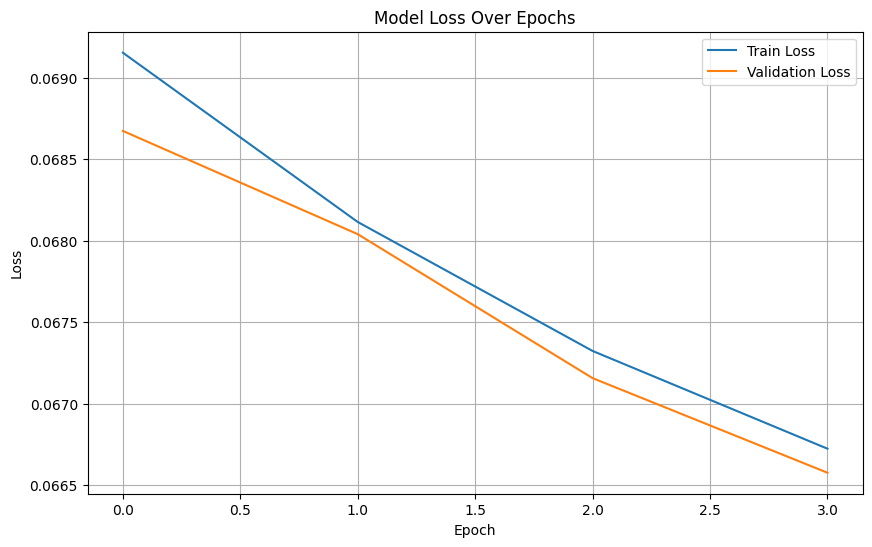

In [ ]:
# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()